This notebook tests basic simulation by recapitulating a simulated dataset several times and measuring variance.

Imports

In [1]:
import sys
import os
package_path = os.path.abspath("..")
sys.path.insert(0, package_path)
#The path will be managed by conda or whatever on release, but this is fine for now.
import scMPRAforge as scm
import pandas as pd
import numpy as np

In [1]:
#load the autoreload extension
%load_ext autoreload
#reload code on every execution
#(this may break objects)
#you can remove this & do dev in a notebook, then paste into the module when you are done.
%autoreload 2

In [2]:
#dask imports
from dask_jobqueue import SLURMCluster
from dask.distributed import Client, LocalCluster
import socket

Make the dask cluster & client in accordance with resource avail and model size

In [3]:
cluster=LocalCluster()
#cluster=SLURMCluster(
#    cores=2,#cores per slurm job
#    memory="16G",#memory per slurm job
#    processes=1,#dask workers per slurm job
#    job_extra_directives=["-p ycga", 
#        f"--job-name=simclust_worker",
#        f"--time=2:00:00",
#        f"--output=slave_%j.out"]
#)
client = Client(cluster,
    timeout=f"{5*60}s",   # Client <-> scheduler timeout 
    heartbeat_interval="20s"  # Worker heartbeat interval
)

2025-06-10 13:09:01,676 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 76bbd512c5d23e4c334e9d34b793e0bb initialized by task ('shuffle-transfer-76bbd512c5d23e4c334e9d34b793e0bb', 0) executed on worker tcp://127.0.0.1:63048
2025-06-10 13:09:01,696 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 1845213918f6d82bfdf2745b9285e16d initialized by task ('shuffle-transfer-1845213918f6d82bfdf2745b9285e16d', 0) executed on worker tcp://127.0.0.1:63048
2025-06-10 13:09:01,955 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 1845213918f6d82bfdf2745b9285e16d deactivated due to stimulus 'task-finished-1749575341.954689'
2025-06-10 13:09:01,959 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 76bbd512c5d23e4c334e9d34b793e0bb deactivated due to stimulus 'task-finished-1749575341.9590888'
2025-06-10 13:09:02,397 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 035ee21af00e2e90192a428aefa4ed6d initialized by task ('shuffle-transfer-035ee21af00e2e9

In [ ]:
class simulation_batch:
    """
    Class which takes a single <ortho> object and simulates replicates.
    Optionally, fits additional ortho objects to simulations (currently mandatory : change)
    Useful for 
    """
    pass

In [4]:
#cluster.scale(jobs=5)

In [4]:
dat=scm.load_scMPRA_data("/gpfs/gibbs/pi/reilly/tabula_data/simulated/fake_cres.tsv")

In [5]:
dat.drop("Unnamed: 0", axis=1, inplace=True)

In [6]:
#let's make an ortho object out of the data on disc, we'll call 'primordial'
primordial=scm.ortho()
primordial.criss_cross(client=client,dat=dat)
primordial.extract_params(client)

In [7]:
# break out data-frame descriptions of the by-cre and by-cell-type parameters.
description_primordial_by_cre=scm.describe_parameters(client,parameters=primordial.by_cre_parameters.result(),dat=dat,split="cre_id")
description_primordial_by_cre=scm.auto_partition(description_primordial_by_cre,50)

description_primordial_by_cell_type=scm.describe_parameters(client,parameters=primordial.by_cell_type_parameters.result(),dat=dat,split="cell_type")
description_primordial_by_cell_type=scm.auto_partition(description_primordial_by_cell_type,50)


In [8]:
def split_dataframe_by_column(df, column):
    """
    Splits a DataFrame into a dictionary of DataFrames based on unique values in a given column.

    Parameters:
    df (pd.DataFrame): The input DataFrame.
    column (str): The column name to split on.

    Returns:
    dict: A dictionary where keys are unique column values and values are DataFrames.
    """
    return {value: sub_df for value, sub_df in df.groupby(column)}

def bust_up(working, split):
    """Breaks a round of simulation into sub-tables, one for each of the major parameters in the zinb"""
    drop_from_zi=[i for i in ['cre_id','cells','nb','theta','p','r','sigmasquare','cell_type'] if i != split]
    zi=working.drop(columns=drop_from_zi)
    zi=zi.drop_duplicates()#.groupby("rep_id").agg('mean')# zi
    
    nb=working.drop(columns=['rep_id','cells','zi','theta','r','p','sigmasquare']).drop_duplicates()# nb
    
    #for theta, we have only one value per model : one value per value of split column. 
    #this means we want to drop the anti-split column, since this provides no info
    theta_to_drop=[i for i in working.columns.to_list() if i not in [split,'theta']]
    theta=working.drop(columns=theta_to_drop).drop_duplicates()
    return {'zi':zi,'nb':nb,'theta':theta}

def round_of_simu(client,description_primordial):
    """
    Given a description of parameters, simulate a round of data, fit a description & return
    """
    #s for simulated
    s=scm.simulate_from_description(description_primordial).compute()
    
    s=scm.undo_one_hot_encoding(s)
    s=s.rename({'zinb_sample':'umis_mpra_bc'},axis=1)[['rep_id','cre_id','cell_type','umis_mpra_bc']]

    #recap as in recapitulating the primordial parameters
    recap=scm.ortho()
    recap.criss_cross(client=client,dat=s)
    recap.extract_params(client)

    return recap



In [9]:
#first is primordial, second is fit
from_cre=[]
from_cell_type=[]

for _ in range(1,5):
    from_cre.append(round_of_simu(client,description_primordial_by_cre))
    from_cell_type.append(round_of_simu(client,description_primordial_by_cell_type))
    #cre_to_cell_type.append(round_of_simu(description_primordial_by_cre,split="cell_type"))

In [97]:
x=pd.DataFrame([from_cre[0].by_cell_type_parameters.result().theta]).T

x=x.reset_index()
x.columns=["abc","123"]
x

,abc,123
0,blood,1.2960724
1,brain,1.248935


In [93]:
x.columns

RangeIndex(start=0, stop=1, step=1, name='abc')

In [128]:
splits=["cre_id","cell_type"]
vars=["nb","zi","theta"]

nbs=[]
zi_cre=[]
zi_cell=[]

theta_cre=[]
theta_cell=[]

def flatten_results(working,split:str,var:str):
    
    if split not in splits or var not in vars:
        raise ValueError("invalid chocie")
    #add check for valid working split var
    
    if var=="theta":
        if split=="cre_id":
            working=working.by_cre_parameters.result()
        elif split=="cell_type":
            working=working.by_cell_type_parameters.result()
        
        working=pd.DataFrame([working.theta]).T
        working=working.reset_index()
        working.columns=[split,"theta"]
        working['theta']=working['theta'].astype(float)
        return working

    if split=="cre_id":
        working=working.by_cre_parameters.result()
    elif split=="cell_type":
        working=working.by_cell_type_parameters.result()
    if var =="nb":
        working=pd.concat(working.nb)
    elif var =="zi":
        working=pd.concat(working.zi)
    working.index=working.index.set_names(split,level=0)
    working=working.reset_index()
    working=scm.undo_one_hot_encoding(working)
    return working

#add primordial for reference
for split in splits:
    for var in ["nb","zi","theta"]:
        #nb
        prim_flattened=flatten_results(primordial,split,var)
        prim_flattened["id"]=f"primordial {split}"
        prim_flattened["rep"]="primordial"
        if var=="nb":
            nbs.append(prim_flattened)
        elif var=="zi":
            if split=="cre_id":
                zi_cre.append(prim_flattened)
            elif split=="cell_type":
                zi_cell.append(prim_flattened)
        elif var=="theta":
            if split=="cre_id":
                theta_cre.append(prim_flattened)
            elif split=="cell_type":
                theta_cell.append(prim_flattened)


for _from in splits:
    orthos=None
    if _from=="cre_id":
        orthos=from_cre
    else:
        orthos=from_cell_type
    
    for _to in splits:
        
        id_string=f"{_from}->{_to}"
        for i, ortho in enumerate(orthos):

            #ugly duplicated code, fix...

            #nb
            working=flatten_results(ortho,split=_to,var="nb")
            working['id']=id_string
            working['rep']=f"rep {i}"
            nbs.append(working)

            #zi
            working=flatten_results(ortho,split=_to,var="zi")
            working['id']=id_string
            working['rep']=f"rep {i}"
            if _to=="cre_id":
                zi_cre.append(working)
            else:
                zi_cell.append(working)

            #theta
            working=flatten_results(ortho,split=_to,var="theta")
            working['id']=id_string
            working['rep']=f"rep {i}"
            if _to=="cre_id":
                theta_cre.append(working)
            else:
                theta_cell.append(working)



nbs=pd.concat(nbs)
zi_cre=pd.concat(zi_cre)
zi_cell=pd.concat(zi_cell)
theta_cre=pd.concat(theta_cre)
theta_cell=pd.concat(theta_cell)

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

In [126]:
# Print types in the split column
print(theta_cell["theta"].apply(type).value_counts())

theta
<class 'numpy.ndarray'>    18
Name: count, dtype: int64


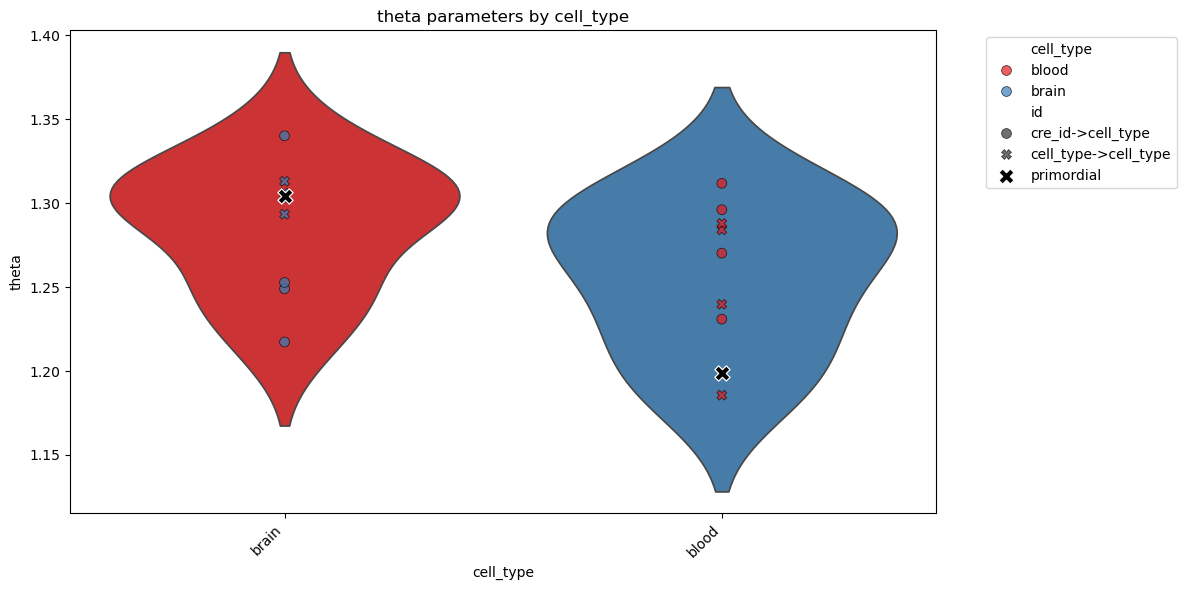

In [133]:
def plot_theta_spread(theta, split):
    #no need to copy : no mutation
    #theta=theta.copy()
    
    plt.figure(figsize=(12, 6))

    #basic violin plot
    sns.violinplot(
        data=theta, x=split, y='theta',
        inner=None, palette='Set1'
    )

    # Regular points
    sns.scatterplot(
        data=theta[~theta['id'].isin(['primordial cre_id', 'primordial cell_type'])],
        x=split, y='theta',
        hue=split, style='id',
        palette='Set1', edgecolor='black', s=50, alpha=0.7, legend='brief'
    )

    # Primordial points overlay (bold black Xs)
    sns.scatterplot(
        data=theta[theta['id'].isin(['primordial cre_id', 'primordial cell_type'])],
        x=split, y='theta',
        color='black', marker='X',
        s=120, label='primordial', zorder=10
    )

    plt.xlabel(f'{split}')
    plt.ylabel('theta')
    plt.title(f'theta parameters by {split}')
    plt.xticks(rotation=45, ha='right')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


plot_theta_spread(theta_cell,split="cell_type")

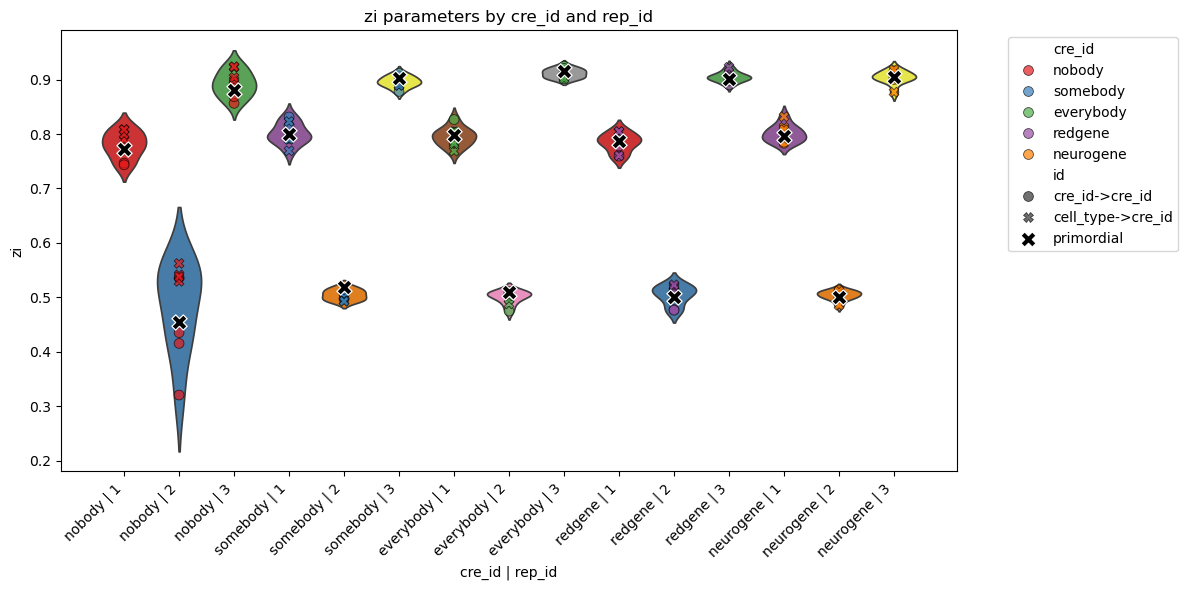

In [ ]:
def plot_zi_spread(zi,split):
    zi=zi.copy()
    zi['group']=zi[split] + " | " + zi["rep_id"]

    plt.figure(figsize=(12, 6))
    
    #basic violin plot
    sns.violinplot(
        data=zi, x='group', y='zi',
        inner=None, palette='Set1'
    )

    # Regular points
    sns.scatterplot(
        data=zi[~zi['id'].isin(['primordial cre_id', 'primordial cell_type'])],
        x='group', y='zi',
        hue=split, style='id',
        palette='Set1', edgecolor='black', s=50, alpha=0.7, legend='brief'
    )

    # Primordial points overlay (bold black Xs)
    sns.scatterplot(
        data=zi[zi['id'].isin(['primordial cre_id', 'primordial cell_type'])],
        x='group', y='zi',
        color='black', marker='X',
        s=120, label='primordial', zorder=10
    )
    

    plt.xlabel(f'{split} | rep_id')
    plt.ylabel('zi')
    plt.title(f'zi parameters by {split} and rep_id')
    plt.xticks(rotation=45, ha='right')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

plot_zi_spread(zi_cre,split="cre_id")
#plot_zi_spread(zi_cell,split="cell_type")

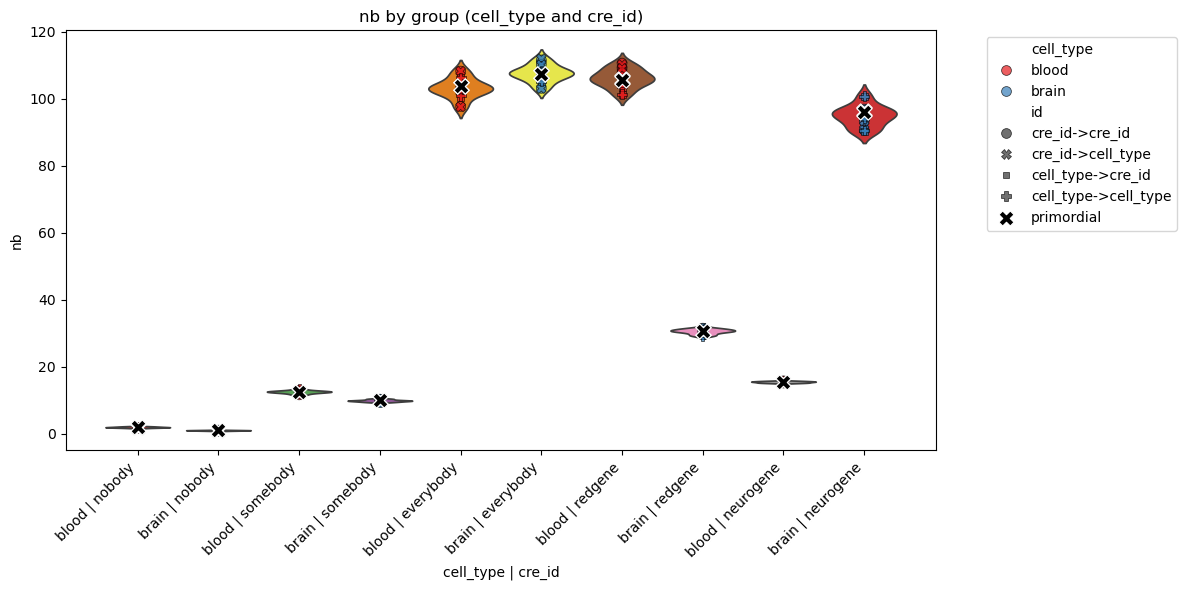

In [ ]:
def plot_nb_spread(nbs):
    nbs=nbs.copy()
    nbs['group'] = nbs['cell_type'] + " | " + nbs['cre_id']

    plt.figure(figsize=(12, 6))

    # Violin plot
    sns.violinplot(
        data=nbs, x='group', y='nb',
        inner=None, palette='Set1'
    )

    # Regular points
    sns.scatterplot(
        data=nbs[~nbs['id'].isin(['primordial cre_id', 'primordial cell_type'])],
        x='group', y='nb',
        hue='cell_type', style='id',
        palette='Set1', edgecolor='black', s=50, alpha=0.7, legend='brief'
    )

    # Primordial points overlay (bold black Xs)
    sns.scatterplot(
        data=nbs[nbs['id'].isin(['primordial cre_id', 'primordial cell_type'])],
        x='group', y='nb',
        color='black', marker='X',
        s=120, label='primordial', zorder=10
    )

    plt.xlabel('cell_type | cre_id')
    plt.ylabel('nb')
    plt.title('nb parameters by cell_type and cre_id')
    plt.xticks(rotation=45, ha='right')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
plot_nb_spread(nbs)

In [135]:
cluster.close()